In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ACDM_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_001656-1l190haz/files/checkpoint_last.p"
ACDM_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_131146-xn639xgt/files/checkpoint_last.p"
ACDM = misc.load_MNLCD(ACDM_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
ACDM.config

{'model_type': 'ModernUnet',
 'input_channels': 2,
 'output_channels': 2,
 'hidden_channels': 64,
 'norm': False,
 'dim_mults': [2, 2, 2],
 'n_blocks': 2,
 'mid_attn': False,
 'is_attn': (False, False, False, False),
 'activation': 'gelu',
 'image_width': 64,
 'image_height': 64,
 'first_embedding_dim': 512,
 'second_embedding_dim': 512,
 'third_embedding_dim': None,
 'save_path': '/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_131146-xn639xgt/files',
 'save_name': 'model_weights.pt',
 'diffusion_steps': 100,
 'project': 'ICML2026',
 'wandb_run_name': 'MNLCD_100',
 'wandb_log_freq': 100,
 'ddp': False,
 'PDE': 'Kolmogorov',
 'file_path': '/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/small_ACDM_training_data.p',
 'subsample': None,
 'train_ratio': 0.95,
 'loader_workers': 1,
 'optimization': {'epochs': 200,
  'lr': 0.0002,
  'wd': 0.05,
  'batch_size': 64,
  'gradient_clip': 1.0,
  'scheduler_step': 100000,
  'scheduler_gamma': 0.5},
 'n_sims': 1000,
 'n_traj': 10,
 'ch

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"]/4.44
data_dict["data_config"]

/state/partition1/job-1136188/ipykernel_3519697/2483025451.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_fl

{'n_sims': 5,
 'n_traj': 1,
 'chunk_size': 10000,
 'nsteps': 100000,
 'dt': 0.001,
 'Dt': 0.002,
 'spinup': 10000,
 'decorr_steps': 0,
 'reynolds': 10000,
 'gridsize': 512,
 'downsample': 8,
 'save_path': '/scratch/ql2221/thermalizer_data/kolmogorov/reynold10k/Long_numerical_rollout.p',
 'viscosity': 0.0001,
 'Dt/dt': 2.0}

In [4]:
x = data[0:1].to(device)

#getting x_t and noise it
x_t = x[:,-1:]
noise_t = torch.randn_like(x[:,-1:]).to(device)
s_t = torch.tensor([80]).to(device)
x_t_noised = ACDM._forward_diffusion(x_t, s_t, noise_t).to(device)

In [5]:
import CT.Models.Classifier as Classifier
# Classifier_filestring = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_002301-l9yz4wz6/files/checkpoint_last.p"
Classifier_filestring = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260124_131146-xbnd3lou/files/checkpoint_last.p"
Classifier_model_dict = torch.load(Classifier_filestring)
classifier = Classifier.Classifier(Classifier_model_dict["config"])
classifier.load_state_dict(Classifier_model_dict["state_dict"])
classifier = classifier.to(device)

/state/partition1/job-1136188/ipykernel_3519697/4026604309.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Classifier_model_dict = torch.load(Classifier_filestring)


In [6]:
x_short = x[:,-2:-1].to(device)
s_short = torch.tensor([20]).to(device)
noise_short = torch.randn_like(x[:,-1:]).to(device)
x_short = ACDM._forward_diffusion(x_short, s_short, noise_short).to(device)
s = torch.cat((s_short.unsqueeze(0), s_t.unsqueeze(0)), dim=1).to(device)
x_conditional = torch.cat((x_short, x_t_noised), dim=1).to(device)
# s = classifier.ratio_class_both(x_conditional, None, None, None).to(device)
x_denoised = ACDM.denoising(x_conditional, s)

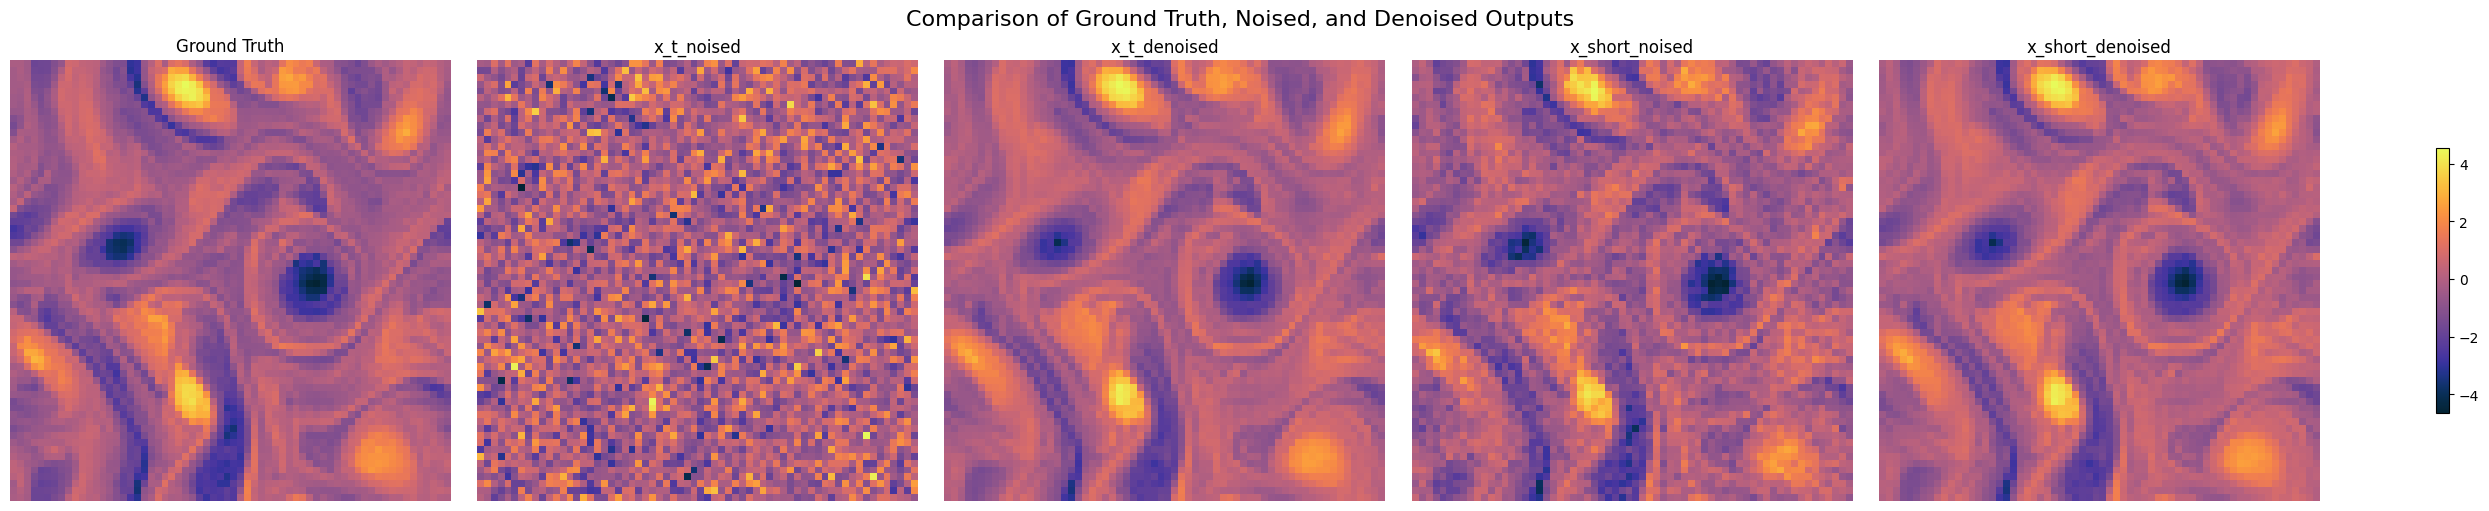

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t,                
    x_t_noised,
    x_denoised[:,-1:],
    x_short,
    x_denoised[:,-2:-1]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_short_noised',
    'x_short_denoised'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
def MNLCD_refinement(ics, emu, MNLCD, Classifier, n_steps=1000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, starting_time = 1000, sigma=None, silence=False,  forward_diff = True, fix_short = False, fix_short_noise_level = 0, fix_noise_level_t = None, device = "cuda"):
    B, _, X, Y = ics.shape
    state_vector=torch.zeros((B,n_steps,X,Y),device=device)

    state_vector[:,0:1]=ics.to(device)
    short_lag = torch.full((B,), short_lag_int, dtype=torch.int64, device=device)
    with torch.no_grad():
        for aa in tqdm(range(1, n_steps), disable=silence):
            prev = state_vector[:, aa - 1]
            state_vector[:, aa] = emu(prev.unsqueeze(1)).squeeze() + prev

            if sigma is not None:
                state_vector[:, aa] += sigma * torch.randn_like(state_vector[:, aa],device=state_vector[:, aa].device,)
            if aa % freq != 0 or aa - starting_time < 0:
                continue 

            batch_idx = torch.arange(B, device=device)
            x_t_noised = state_vector[:, aa].unsqueeze(1)
            x_t_minus_short_lag = state_vector[:, aa - lag_ratio * short_lag_int].unsqueeze(1)
            
            x_conditional = torch.cat((x_t_minus_short_lag, x_t_noised), dim = 1)
            pred_noise_levels = Classifier.ratio_class_both(x_conditional, None, None, None).to(device)
            if fix_short_noise_level is not None:
                pred_noise_levels[:,-2:-1] = fix_short_noise_level
            if fix_noise_level_t is not None:
                pred_noise_levels[:,-1:] = fix_noise_level_t
            pred_s_t = pred_noise_levels[:,-1:]
            pred_s_short = pred_noise_levels[:,-2:-1]

            mask = (pred_s_t < s_init)
            pred_noise_levels[mask.squeeze(), -2:] = 0
            
            if pred_s_t.max() > s_init:
                if fix_short:
                    state_vector[:, aa:aa+1] = MNLCD.denoising_t_only(x_conditional, pred_noise_levels, forward_diff)[:,-1:,:,:]
                else:
                    combined_vector = MNLCD.denoising(x_conditional, pred_noise_levels, forward_diff)
                    state_vector[:, aa:aa+1] = combined_vector[:,-1:,:,:]
                    state_vector[:,aa-1:aa] = combined_vector[:,-2:-1]
    return state_vector

In [9]:
Emu_file_path = "/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251209_020651-5dziwzqp/files/checkpoint_best.p" #worse emulator
Emu = misc.load_Emulator(Emu_file_path).to(device)

x = data.to(device)
rollout = MNLCD_refinement(x[:,0:1], Emu, ACDM, classifier, n_steps=10000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, starting_time = 1000, sigma=None, silence=False, forward_diff = True, fix_short = False, fix_short_noise_level = None, fix_noise_level_t = None, device = "cuda")

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)
100%|██████████| 9999/

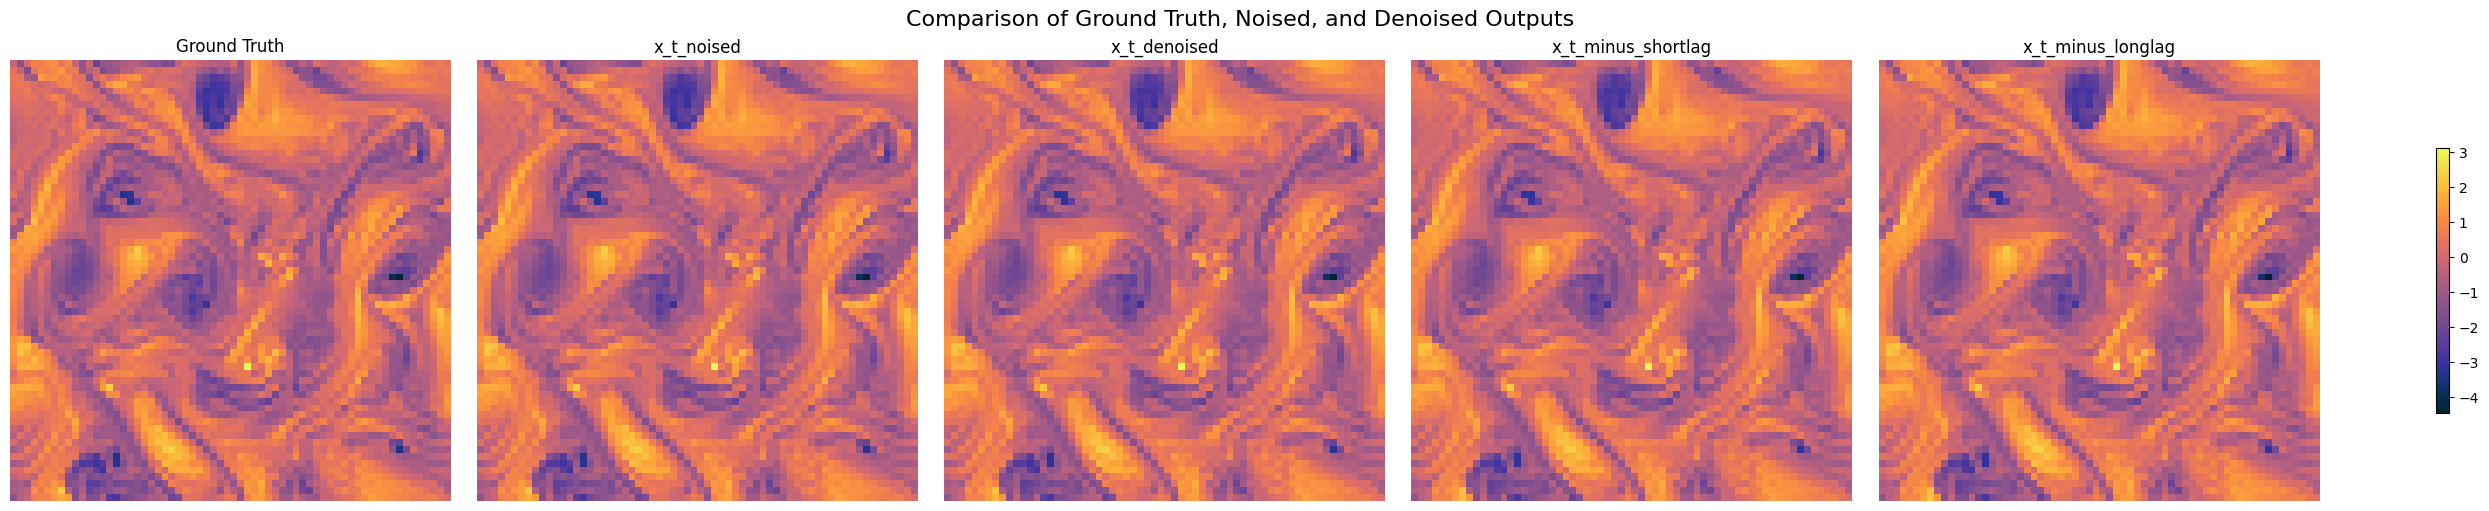

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
T = 9005
B = 4
tensors = [
    rollout[B:B+1,T-1:T],                
    rollout[B:B+1,T-2:T-1],
    rollout[B:B+1,T-3:T-2],
    rollout[B:B+1,T-4:T-3],
    rollout[B:B+1,T-5:T-4]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [11]:
def MNLCD_generation(ics, MNLCD, Classifier, n_steps=1000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, s_t = 99, sigma=None, silence=False,  forward_diff = True, fix_short = False, freeze_short = False, noise_short = False, refinement = False, device = "cuda"):
    B, _, X, Y = ics.shape
    state_vector=torch.zeros((B,n_steps,X,Y),device=device)

    state_vector[:,0:1]=ics.to(device)
    short_lag = torch.full((B,), short_lag_int, dtype=torch.int64, device=device)
    with torch.no_grad():
        for aa in tqdm(range(1, n_steps), disable=silence):
            prev = state_vector[:, aa - 1:aa]
            x_t_noised = MNLCD._forward_diffusion(prev, s_t).to(device)
            x_conditional = torch.cat((prev, x_t_noised), dim = 1)

            pred_noise_levels = Classifier.ratio_class_both(x_conditional, None, None, None).to(device)
            pred_noise_levels[:,-1] = s_t

            if noise_short:
                s_short = pred_noise_levels[:,-2:-1]
                x_conditional[:,0:1] = MNLCD._forward_diffusion(prev, s_short).to(device)

            if freeze_short:
                state_vector[:, aa:aa+1] = MNLCD.denoising_t_only(x_conditional, pred_noise_levels, forward_diff)[:,-1:,:,:]
            else:
                combined_vector = MNLCD.denoising(x_conditional, pred_noise_levels, forward_diff)
                state_vector[:, aa:aa+1] = combined_vector[:,-1:,:,:]
                state_vector[:,aa-1:aa] = combined_vector[:,-2:-1]

            if refinement:
                if aa % freq != 0 or aa - starting_time < 0:
                    continue 
    
                batch_idx = torch.arange(B, device=device)
                x_t_noised = state_vector[:, aa].unsqueeze(1)
                x_t_minus_short_lag = state_vector[:, aa - lag_ratio * short_lag_int].unsqueeze(1)
                
                x_conditional = torch.cat((x_t_minus_short_lag, x_t_noised), dim = 1)
                pred_noise_levels = Classifier.ratio_class_both(x_conditional, None, None, None).to(device)
                if fix_short_noise_level is not None:
                    pred_noise_levels[:,-2:-1] = fix_short_noise_level
                if fix_noise_level_t is not None:
                    pred_noise_levels[:,-1:] = fix_noise_level_t
                pred_s_t = pred_noise_levels[:,-1:]
                pred_s_short = pred_noise_levels[:,-2:-1]
    
                mask = (pred_s_t < s_init)
                pred_noise_levels[mask.squeeze(), -2:] = 0
                
                if pred_s_t.max() > s_init:
                    if fix_short:
                        state_vector[:, aa:aa+1] = MNLCD.denoising_t_only(x_conditional, pred_noise_levels, forward_diff)[:,-1:,:,:]
                    else:
                        combined_vector = MNLCD.denoising(x_conditional, pred_noise_levels, forward_diff)
                        state_vector[:, aa:aa+1] = combined_vector[:,-1:,:,:]
                        state_vector[:,aa-1:aa] = combined_vector[:,-2:-1]
    return state_vector

In [12]:
MNLCD_rollout = MNLCD_generation(x[:,0:1], ACDM, classifier, n_steps=1000, short_lag_int = 1, freq = 1, lag_ratio = 1, s_init = 0, s_t = 50, sigma=None, silence=False,  forward_diff = True, fix_short = False, freeze_short = False, noise_short = False, refinement = False, device = "cuda")

 12%|█▏        | 120/999 [00:55<06:46,  2.16it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
T = 900
B = 0
tensors = [
    MNLCD_rollout[B:B+1,T-1:T],                
    MNLCD_rollout[B:B+1,T-2:T-1],
    MNLCD_rollout[B:B+1,T-3:T-2],
    MNLCD_rollout[B:B+1,T-4:T-3],
    MNLCD_rollout[B:B+1,T-5:T-4]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
emu_rollout = performance.run_emu(x[:,0:1],emu = Emu, n_steps=30000,silent=False,sigma=None)

NameError: name 'performance' is not defined

In [9]:
import os
import numpy as np
import matplotlib
matplotlib.use("Agg")  # safe on headless/HPC
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib as mpl

def make_movie(state_vector, save_path="ACDM_1layer.mp4", fps=30,
                      vmin=None, vmax=None, stride=10, cmap=None):
    """
    Movie for a *single-layer* field stored as a 4D/5D tensor:

      - supported shapes:
          (B, T, H, W)            or
          (B, T, 1, H, W)

    Behavior:
      - uses imageio-ffmpeg if available
      - uses codec='mpeg4' to avoid libx264 dependency
      - symmetric vmin/vmax if not provided
      - plots B rows x 1 column (one panel per batch)
      - optional GIF fallback if MP4 fails
    """

    # Prefer self-contained ffmpeg (HPC/Singularity-safe)
    try:
        import imageio_ffmpeg as iio
        mpl.rcParams["animation.ffmpeg_path"] = iio.get_ffmpeg_exe()
    except Exception:
        pass

    # Default colormap
    if cmap is None:
        cmap = "viridis"

    # Normalize input shape
    arr = state_vector
    if hasattr(arr, "detach"):
        arr = arr.detach().cpu().numpy()
    else:
        arr = np.asarray(arr)

    if arr.ndim == 4:
        # (B, T, H, W)
        B, T, H, W = arr.shape
        data = arr
    elif arr.ndim == 5:
        # (B, T, 1, H, W)
        B, T, L, H, W = arr.shape
        assert L == 1, f"Expected L==1 for single-layer movie, got L={L}"
        data = arr[:, :, 0]  # -> (B, T, H, W)
    else:
        raise ValueError(f"Expected 4D (B,T,H,W) or 5D (B,T,1,H,W); got shape {arr.shape}")

    frame_indices = list(range(0, T, stride))

    # vmin/vmax: if not provided, use symmetric global limits across all batches/times
    if vmin is None or vmax is None:
        m = float(np.nanmax(np.abs(data)))
        vmin = -m
        vmax =  m

    # Layout: B rows x 1 col
    fig, axes = plt.subplots(B, 1, figsize=(6, 4.5 * B), squeeze=False)
    ims = [None] * B

    for b in range(B):
        ax = axes[b, 0]
        im = ax.imshow(
            data[b, 0],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            origin="upper",
        )
        ax.set_title(f"Batch {b} — Timestep 0")
        ax.set_xticks([])
        ax.set_yticks([])
        ims[b] = im

    # One shared colorbar for all batches
    fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.9)

    def update(k):
        t = frame_indices[k]
        artists = []
        for b in range(B):
            ims[b].set_data(data[b, t])
            axes[b, 0].set_title(f"Batch {b} — Timestep {t}")
            artists.append(ims[b])
        return artists

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frame_indices),
        blit=False,
        repeat=False
    )

    # Save MP4 with MPEG-4 Part 2 (no x264)
    try:
        Writer = animation.writers["ffmpeg"]
        writer = Writer(
            fps=fps,
            codec="mpeg4",
            bitrate=20000,
            extra_args=["-pix_fmt", "yuv420p"]
        )
        ani.save(save_path, writer=writer)
        print(f"movie saved: {save_path}")
    except Exception as e:
        base, _ = os.path.splitext(save_path)
        gif_path = base + ".gif"
        print(f"MP4 save failed ({type(e).__name__}: {e}). Falling back to GIF: {gif_path}")

        writer = animation.PillowWriter(fps=fps)
        ani.save(gif_path, writer=writer)
        print(f"movie saved: {gif_path}")
    finally:
        plt.close(fig)


In [10]:
make_movie(rollout)

movie saved: ACDM_1layer.mp4


In [11]:
make_movie(x[0:1,0:10000], save_path="GT.mp4")

movie saved: GT.mp4
